#### Używamy szybkiej transformaty Fouriera, aby przekształcić .wav, nasz szereg czasowy, ze skali czasu na skalę częstotliwości.

Spectral leakage -


#### Skorzystamy ze zbioru danych TinySOL (URL: https://zenodo.org/records/3685367)
#### W tym celu pobieramy bibliotekę mirdata zawierającą dataset loader

In [33]:
import pandas as pd
import numpy as np

import wave
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf

from IPython.display import Audio, display
from pathlib import Path

In [13]:
# Szukamy plików .wav
dataset_path = Path('tiny_data')
audio_files = sorted(list(dataset_path.rglob("*.wav")))

print(f"Znalezione pliki .wav: {len(audio_files)}")

Znalezione pliki .wav: 42


In [109]:
# Przykładowy plik
sample_file = audio_files[1]
audio_signal, sample_rate = sf.read(sample_file)

file_name = sample_file.stem
metadata = file_name.split('-')

print(f"Plik {sample_file.name}")
print(f"Kod instrumentu: {metadata[0]}, Nuta: {metadata[2]}, Dynamika: {metadata[3]}")
print(f"Częstotliwość próbkowania: {sample_rate} Hz | Liczba próbek: {audio_signal.shape[0]}")

# Konwersja pliku do mono (jeśli był w stereo)
if audio_signal.ndim > 1:
    audio_signal = np.mean(audio_signal, axis = 1)

# Odtwarzacz
display(Audio(audio_signal, rate = sample_rate))



Plik Cb-ord-C4-ff-2c-T20u.wav
Kod instrumentu: Cb, Nuta: C4, Dynamika: ff
Częstotliwość próbkowania: 44100 Hz | Liczba próbek: 151220


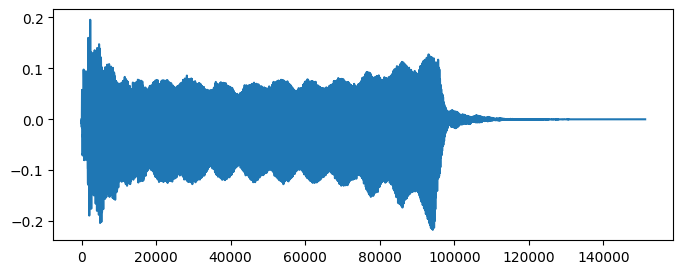

In [110]:
plt.figure(figsize=(8,3))
plt.plot(audio_signal) # "Żuk Mandelbrota"
plt.show()

In [165]:
def plot_audiowave(signal, sr = 44100, zoom_ms = 50,figsize = (12,8)):
    number_of_samples = len(signal)
    duration_seconds = number_of_samples/sr

    t = np.arange(len(signal))/ sr
    peak_amp = np.max(np.abs(signal))

    fig, (ax, ax_zoom) = plt.subplots(2,1, figsize = figsize)

    # Pełny sygnał
    ax.plot(t,signal,linewidth =.6, alpha =.8, label = "Amplituda")
    ax.set_xlim(0, duration_seconds)
    #ax.set_ylim(-0.5, 0.5)
    ax.set_ylabel("Amplituda")
    ax.set_xlabel("Czas [s]")
    ax.grid(True, linestyle="-", alpha=0.5)

    # Wycinek sygnału
    zoom_start_sec = max(0.0, (duration_seconds / 2) - (zoom_ms / 2000.0))
    zoom_end_sec = min(duration_seconds, zoom_start_sec + (zoom_ms / 1000.0))
    ax.axvspan(
        zoom_start_sec,
        zoom_end_sec,
        color="orange",
        alpha=0.3,
        label=f"Wycinek ({zoom_ms} ms)",
    )
    ax.legend(loc="upper right", framealpha=0.9)

    start_idx = int(zoom_start_sec * sr)
    end_idx = int(zoom_end_sec * sr)

    t_zoom_ms = (t[start_idx:end_idx] - zoom_start_sec) * 1000.0
    signal_zoom = signal[start_idx:end_idx]

    ax_zoom.plot(
        t_zoom_ms,
        signal_zoom,
        color="red",
        linewidth=1.5,
        markersize=2,
    )
    ax_zoom.axhline(0, color="black", linestyle="--", linewidth=0.7, alpha=0.6)
    ax_zoom.set_xlim(0, (zoom_end_sec - zoom_start_sec) * 1000.0)
    ax_zoom.set_ylabel("Amplituda")
    ax_zoom.set_xlabel("Czas [ms]")
    ax_zoom.set_title(
        f"Fragment fali (okno {zoom_ms} ms)",
        fontsize=10,
    )
    ax_zoom.grid(True, linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.show()


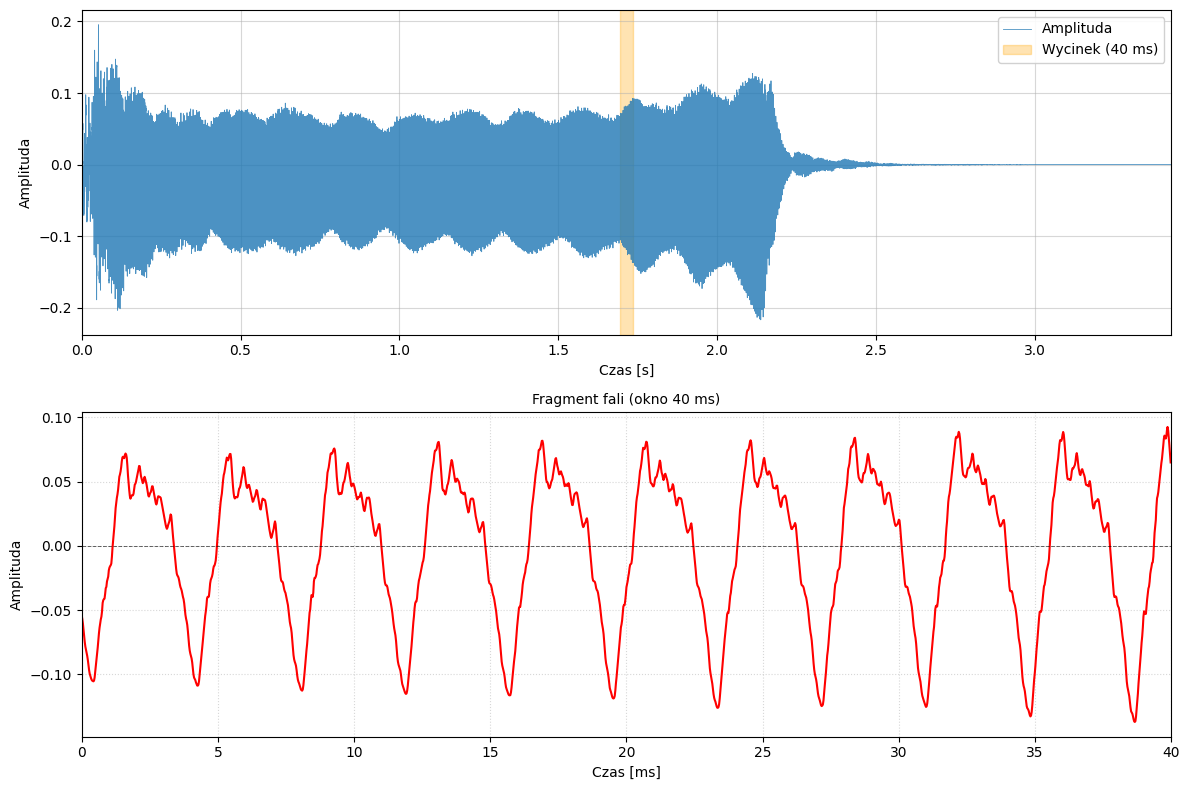

In [166]:
plot_audiowave(audio_signal, zoom_ms= 40)

### Etap 1. Framing + Overlap
Musimy pociąć plik audio na fragmenty (okna, które nachodzą na siebie). Musimy zdefiniować parametry:
- długość okna $N$,
- krok przesunięcia $H$,
- liczba ramek $K$.

In [ ]:
def frame_audio(audio_data, N, H):

### Etap 2. Okienkowanie

### Mel Filterbank
Nakładanie filtrów trójkątnych, aby wyeliminować możliwy przeciek widma (spectral leakage)